Saving WhatsApp Image 2025-04-30 at 3.07.39 PM.jpeg to WhatsApp Image 2025-04-30 at 3.07.39 PM.jpeg
Image loaded successfully.
Virtual robot arm initialized.
Waste sorting system initialized.
Moving arm to position (657, 1244)
Picking up item at position (657, 1244)
Moving to plastic bin at position (100, 500)
Releasing item at position (100, 500)
Moving arm to position (288, 181)
Picking up item at position (288, 181)
Moving to plastic bin at position (100, 500)
Releasing item at position (100, 500)
Moving arm to position (331, 183)
Picking up item at position (331, 183)
Moving to plastic bin at position (100, 500)
Releasing item at position (100, 500)
Moving arm to position (638, 130)
Picking up item at position (638, 130)
Moving to plastic bin at position (100, 500)
Releasing item at position (100, 500)
Moving arm to position (16, 526)
Picking up item at position (16, 526)
Moving to plastic bin at position (100, 500)
Releasing item at position (100, 500)
Moving arm to position (529,

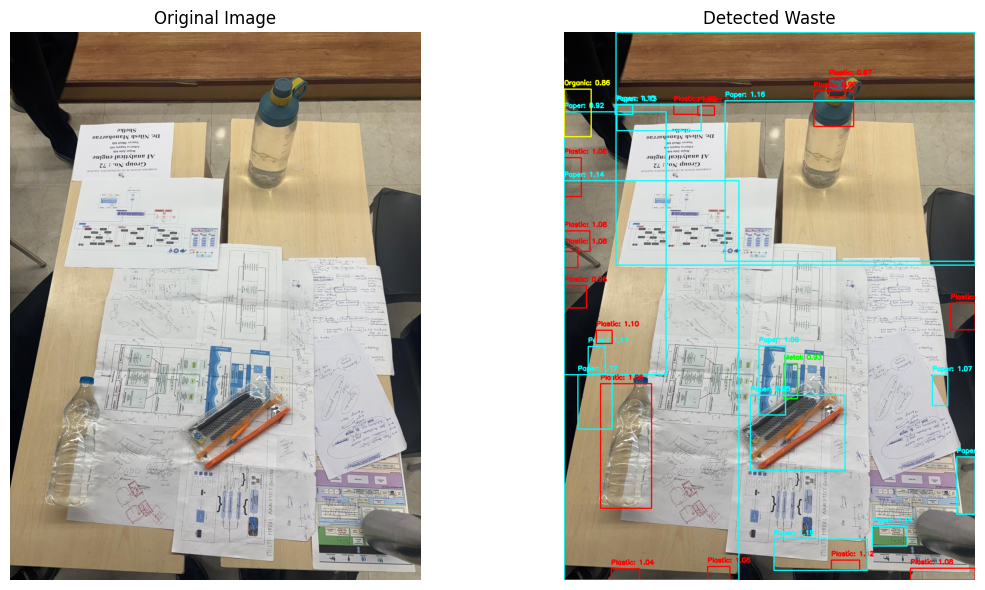

Detected Plastic with confidence 1.12
Detected Plastic with confidence 1.09
Detected Plastic with confidence 1.10
Detected Plastic with confidence 0.87
Detected Plastic with confidence 1.08
Detected Metal with confidence 0.93
Detected Metal with confidence 0.93
Detected Paper with confidence 1.15
Detected Plastic with confidence 1.08
Detected Plastic with confidence 1.08
Detected Paper with confidence 1.15
Detected Plastic with confidence 0.90
Detected Paper with confidence 1.17
Detected Plastic with confidence 0.98
Detected Paper with confidence 0.95
Detected Plastic with confidence 1.04
Detected Paper with confidence 1.14
Detected Paper with confidence 1.13
Detected Paper with confidence 1.16
Detected Plastic with confidence 1.08
Detected Paper with confidence 1.19
Detected Plastic with confidence 1.08
Detected Plastic with confidence 1.10
Detected Plastic with confidence 0.96
Detected Paper with confidence 1.07
Detected Paper with confidence 0.92
Detected Organic with confidence 0.8

In [ ]:
# Step 1: Install necessary packages (only needed once)
!pip install opencv-python-headless matplotlib scikit-learn pandas

# Step 2: Upload files (your Python file and image)
from google.colab import files
uploaded = files.upload()

# Step 3: Load and run your script
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import os
import time
from datetime import datetime

# Step 4: Extract and define classes (from your pbl_2.py)
class VirtualRobotArm:
    def __init__(self):
        self.x = 0
        self.y = 0
        self.holding = False
        self.bin_positions = {
            'plastic': (100, 500),
            'paper': (300, 500),
            'metal': (500, 500),
            'glass': (700, 500),
            'organic': (900, 500)
        }
        print("Virtual robot arm initialized.")

    def move_to(self, x, y):
        print(f"Moving arm to position ({x}, {y})")
        time.sleep(0.1)
        self.x, self.y = x, y

    def pickup(self):
        if not self.holding:
            print(f"Picking up item at position ({self.x}, {self.y})")
            self.holding = True
            time.sleep(0.1)

    def move_to_bin(self, waste_type):
        if waste_type in self.bin_positions:
            bin_x, bin_y = self.bin_positions[waste_type]
            print(f"Moving to {waste_type} bin at position ({bin_x}, {bin_y})")
            time.sleep(0.1)
            self.x, self.y = bin_x, bin_y

    def release(self):
        if self.holding:
            print(f"Releasing item at position ({self.x}, {self.y})")
            self.holding = False
            time.sleep(0.1)


class WasteSortingSystem:
    def __init__(self):
        self.waste_categories = {
            'plastic': {'color_range': [(0, 50, 50), (30, 255, 255)], 'label': 'Plastic'},
            'paper': {'color_range': [(20, 20, 70), (35, 100, 255)], 'label': 'Paper'},
            'metal': {'color_range': [(90, 50, 50), (120, 255, 255)], 'label': 'Metal'},
            'glass': {'color_range': [(70, 50, 50), (90, 255, 255)], 'label': 'Glass'},
            'organic': {'color_range': [(35, 50, 50), (70, 255, 255)], 'label': 'Organic'}
        }
        self.additional_plastic_ranges = [
            [(160, 0, 200), (180, 30, 255)],
            [(100, 50, 50), (130, 255, 255)]
        ]
        self.model_loaded = True
        self.stats = {category: 0 for category in self.waste_categories.keys()}
        self.total_processed = 0
        self.robot_arm = VirtualRobotArm()
        self.log_file = "waste_sorting_log.txt"
        with open(self.log_file, "w") as f:
            f.write(f"Waste Sorting System Log - Started on {datetime.now()}\n")
            f.write("------------------------------------------------------\n")
        print("Waste sorting system initialized.")

    def _calculate_confidence(self, roi_hsv, lower, upper):
        mask = cv2.inRange(roi_hsv, np.array(lower), np.array(upper))
        return np.count_nonzero(mask) / (roi_hsv.shape[0] * roi_hsv.shape[1] + 1e-10)

    def detect_waste(self, image):
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        detected_objects = []
        for category, info in self.waste_categories.items():
            lower, upper = info['color_range']
            mask = cv2.inRange(hsv, np.array(lower), np.array(upper))
            if category == 'plastic':
                for add_range in self.additional_plastic_ranges:
                    add_lower, add_upper = add_range
                    add_mask = cv2.inRange(hsv, np.array(add_lower), np.array(add_upper))
                    mask = cv2.bitwise_or(mask, add_mask)
            kernel = np.ones((5, 5), np.uint8)
            mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for contour in contours:
                if cv2.contourArea(contour) > 500:
                    x, y, w, h = cv2.boundingRect(contour)
                    confidence = self._calculate_confidence(hsv[y:y+h, x:x+w], lower, upper)
                    if category == 'plastic':
                        for add_range in self.additional_plastic_ranges:
                            add_lower, add_upper = add_range
                            add_confidence = self._calculate_confidence(hsv[y:y+h, x:x+w], add_lower, add_upper)
                            confidence = max(confidence, add_confidence)
                    detected_objects.append({
                        'category': category,
                        'label': info['label'],
                        'bbox': (x, y, w, h),
                        'confidence': confidence
                    })
        detected_objects.sort(key=lambda x: x['confidence'], reverse=True)
        return detected_objects

    def classify_waste_by_features(self, image, bbox):
        x, y, w, h = bbox
        roi = image[y:y+h, x:x+w]
        hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
        avg_color = np.mean(hsv_roi, axis=(0, 1))
        gray_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        texture_variance = np.var(gray_roi)
        best_match = None
        best_score = -1
        features = np.append(avg_color, texture_variance)
        for category, info in self.waste_categories.items():
            lower, upper = info['color_range']
            h_dist = min(abs(avg_color[0] - ((lower[0] + upper[0]) / 2)),
                         180 - abs(avg_color[0] - ((lower[0] + upper[0]) / 2))) / 180.0
            s_dist = abs(avg_color[1] - ((lower[1] + upper[1]) / 2)) / 255.0
            v_dist = abs(avg_color[2] - ((lower[2] + upper[2]) / 2)) / 255.0
            color_score = 1.0 - (0.6 * h_dist + 0.2 * s_dist + 0.2 * v_dist)
            if category == 'plastic' and texture_variance < 1000:
                color_score += 0.2
            if category == 'paper' and 1000 <= texture_variance <= 3000:
                color_score += 0.2
            if category == 'plastic':
                for add_range in self.additional_plastic_ranges:
                    add_lower, add_upper = add_range
                    add_h_dist = min(abs(avg_color[0] - ((add_lower[0] + add_upper[0]) / 2)),
                                     180 - abs(avg_color[0] - ((add_lower[0] + add_upper[0]) / 2))) / 180.0
                    add_score = 1.0 - add_h_dist
                    color_score = max(color_score, add_score)
            if color_score > best_score:
                best_score = color_score
                best_match = category
        return best_match, best_score

    def visualize_detection(self, image, detections):
        output = image.copy()
        for detection in detections:
            category = detection['category']
            label = detection['label']
            x, y, w, h = detection['bbox']
            confidence = detection['confidence']
            color = {
                'plastic': (0, 0, 255),
                'paper': (255, 255, 0),
                'metal': (0, 255, 0),
                'glass': (255, 0, 0),
                'organic': (0, 255, 255)
            }.get(category, (255, 255, 255))
            cv2.rectangle(output, (x, y), (x+w, y+h), color, 2)
            cv2.putText(output, f"{label}: {confidence:.2f}", (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        return output

    def sort_waste(self, image):
        detections = self.detect_waste(image)
        if not detections:
            print("No waste detected.")
            return image, []
        for detection in detections:
            category = detection['category']
            bbox = detection['bbox']
            refined_category, confidence = self.classify_waste_by_features(image, bbox)
            detection['category'] = refined_category
            detection['label'] = self.waste_categories[refined_category]['label']
            detection['confidence'] = confidence
            self.stats[refined_category] += 1
            self.total_processed += 1
            x, y, w, h = bbox
            tx, ty = x + w//2, y + h//2
            self.robot_arm.move_to(tx, ty)
            self.robot_arm.pickup()
            self.robot_arm.move_to_bin(refined_category)
            self.robot_arm.release()
        return self.visualize_detection(image, detections), detections

# Step 5: Process the uploaded image
image_path = "WhatsApp Image 2025-04-30 at 3.07.39 PM.jpeg"
image = cv2.imread(image_path)

if image is None:
    print("Error: Could not load image.")
else:
    print("Image loaded successfully.")
    system = WasteSortingSystem()
    output_img, detections = system.sort_waste(image)

    # Step 6: Display original and result side by side
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
    plt.title('Detected Waste')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    for d in detections:
        print(f"Detected {d['label']} with confidence {d['confidence']:.2f}")


Saving WhatsApp Image 2025-05-01 at 10.11.22 AM.jpeg to WhatsApp Image 2025-05-01 at 10.11.22 AM (1).jpeg
Image loaded successfully.
Virtual robot arm initialized.
Waste sorting system initialized.
Moving arm to position (866, 1456)
Picking up item at position (866, 1456)
Moving to plastic bin at position (100, 500)
Releasing item at position (100, 500)
Moving arm to position (863, 1203)
Picking up item at position (863, 1203)
Moving to paper bin at position (300, 500)
Releasing item at position (300, 500)
Moving arm to position (860, 1231)
Picking up item at position (860, 1231)
Moving to paper bin at position (300, 500)
Releasing item at position (300, 500)
Moving arm to position (600, 181)
Picking up item at position (600, 181)
Moving to paper bin at position (300, 500)
Releasing item at position (300, 500)
Moving arm to position (69, 776)
Picking up item at position (69, 776)
Moving to plastic bin at position (100, 500)
Releasing item at position (100, 500)
Moving arm to position (

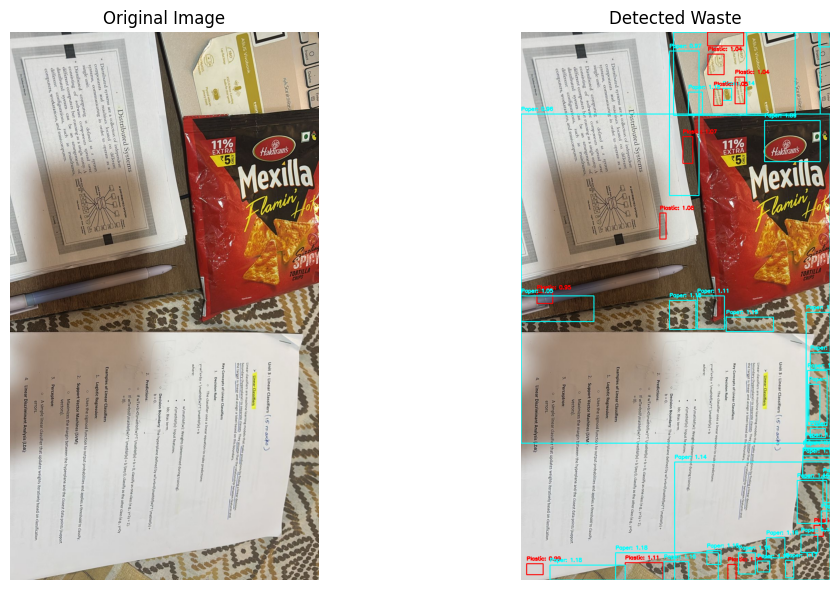

Detected Plastic with confidence 1.08
Detected Paper with confidence 1.16
Detected Paper with confidence 1.13
Detected Paper with confidence 1.14
Detected Plastic with confidence 0.95
Detected Paper with confidence 1.15
Detected Paper with confidence 1.16
Detected Plastic with confidence 1.11
Detected Plastic with confidence 0.99
Detected Paper with confidence 1.16
Detected Plastic with confidence 1.09
Detected Paper with confidence 1.16
Detected Paper with confidence 1.16
Detected Paper with confidence 1.17
Detected Plastic with confidence 1.08
Detected Paper with confidence 1.16
Detected Paper with confidence 1.16
Detected Paper with confidence 1.16
Detected Plastic with confidence 1.07
Detected Paper with confidence 1.15
Detected Plastic with confidence 1.04
Detected Paper with confidence 1.18
Detected Paper with confidence 1.15
Detected Paper with confidence 1.17
Detected Plastic with confidence 1.05
Detected Paper with confidence 1.05
Detected Paper with confidence 1.17
Detected P

In [ ]:
# Step 1: Install necessary packages (only needed once)
!pip install opencv-python-headless matplotlib scikit-learn pandas

# Step 2: Upload files (your Python file and image)
from google.colab import files
uploaded = files.upload()

# Step 3: Load and run your script
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import os
import time
from datetime import datetime

# Step 4: Extract and define classes (from your pbl_2.py)
class VirtualRobotArm:
    def __init__(self):
        self.x = 0
        self.y = 0
        self.holding = False
        self.bin_positions = {
            'plastic': (100, 500),
            'paper': (300, 500),
            'metal': (500, 500),
            'glass': (700, 500),
            'organic': (900, 500)
        }
        print("Virtual robot arm initialized.")

    def move_to(self, x, y):
        print(f"Moving arm to position ({x}, {y})")
        time.sleep(0.1)
        self.x, self.y = x, y

    def pickup(self):
        if not self.holding:
            print(f"Picking up item at position ({self.x}, {self.y})")
            self.holding = True
            time.sleep(0.1)

    def move_to_bin(self, waste_type):
        if waste_type in self.bin_positions:
            bin_x, bin_y = self.bin_positions[waste_type]
            print(f"Moving to {waste_type} bin at position ({bin_x}, {bin_y})")
            time.sleep(0.1)
            self.x, self.y = bin_x, bin_y

    def release(self):
        if self.holding:
            print(f"Releasing item at position ({self.x}, {self.y})")
            self.holding = False
            time.sleep(0.1)


class WasteSortingSystem:
    def __init__(self):
        self.waste_categories = {
            'plastic': {'color_range': [(0, 50, 50), (30, 255, 255)], 'label': 'Plastic'},
            'paper': {'color_range': [(20, 20, 70), (35, 100, 255)], 'label': 'Paper'},
            'metal': {'color_range': [(90, 50, 50), (120, 255, 255)], 'label': 'Metal'},
            'glass': {'color_range': [(70, 50, 50), (90, 255, 255)], 'label': 'Glass'},
            'organic': {'color_range': [(35, 50, 50), (70, 255, 255)], 'label': 'Organic'}
        }
        self.additional_plastic_ranges = [
            [(160, 0, 200), (180, 30, 255)],
            [(100, 50, 50), (130, 255, 255)]
        ]
        self.model_loaded = True
        self.stats = {category: 0 for category in self.waste_categories.keys()}
        self.total_processed = 0
        self.robot_arm = VirtualRobotArm()
        self.log_file = "waste_sorting_log.txt"
        with open(self.log_file, "w") as f:
            f.write(f"Waste Sorting System Log - Started on {datetime.now()}\n")
            f.write("------------------------------------------------------\n")
        print("Waste sorting system initialized.")

    def _calculate_confidence(self, roi_hsv, lower, upper):
        mask = cv2.inRange(roi_hsv, np.array(lower), np.array(upper))
        return np.count_nonzero(mask) / (roi_hsv.shape[0] * roi_hsv.shape[1] + 1e-10)

    def detect_waste(self, image):
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        detected_objects = []
        for category, info in self.waste_categories.items():
            lower, upper = info['color_range']
            mask = cv2.inRange(hsv, np.array(lower), np.array(upper))
            if category == 'plastic':
                for add_range in self.additional_plastic_ranges:
                    add_lower, add_upper = add_range
                    add_mask = cv2.inRange(hsv, np.array(add_lower), np.array(add_upper))
                    mask = cv2.bitwise_or(mask, add_mask)
            kernel = np.ones((5, 5), np.uint8)
            mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for contour in contours:
                if cv2.contourArea(contour) > 500:
                    x, y, w, h = cv2.boundingRect(contour)
                    confidence = self._calculate_confidence(hsv[y:y+h, x:x+w], lower, upper)
                    if category == 'plastic':
                        for add_range in self.additional_plastic_ranges:
                            add_lower, add_upper = add_range
                            add_confidence = self._calculate_confidence(hsv[y:y+h, x:x+w], add_lower, add_upper)
                            confidence = max(confidence, add_confidence)
                    detected_objects.append({
                        'category': category,
                        'label': info['label'],
                        'bbox': (x, y, w, h),
                        'confidence': confidence
                    })
        detected_objects.sort(key=lambda x: x['confidence'], reverse=True)
        return detected_objects

    def classify_waste_by_features(self, image, bbox):
        x, y, w, h = bbox
        roi = image[y:y+h, x:x+w]
        hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
        avg_color = np.mean(hsv_roi, axis=(0, 1))
        gray_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        texture_variance = np.var(gray_roi)
        best_match = None
        best_score = -1
        features = np.append(avg_color, texture_variance)
        for category, info in self.waste_categories.items():
            lower, upper = info['color_range']
            h_dist = min(abs(avg_color[0] - ((lower[0] + upper[0]) / 2)),
                         180 - abs(avg_color[0] - ((lower[0] + upper[0]) / 2))) / 180.0
            s_dist = abs(avg_color[1] - ((lower[1] + upper[1]) / 2)) / 255.0
            v_dist = abs(avg_color[2] - ((lower[2] + upper[2]) / 2)) / 255.0
            color_score = 1.0 - (0.6 * h_dist + 0.2 * s_dist + 0.2 * v_dist)
            if category == 'plastic' and texture_variance < 1000:
                color_score += 0.2
            if category == 'paper' and 1000 <= texture_variance <= 3000:
                color_score += 0.2
            if category == 'plastic':
                for add_range in self.additional_plastic_ranges:
                    add_lower, add_upper = add_range
                    add_h_dist = min(abs(avg_color[0] - ((add_lower[0] + add_upper[0]) / 2)),
                                     180 - abs(avg_color[0] - ((add_lower[0] + add_upper[0]) / 2))) / 180.0
                    add_score = 1.0 - add_h_dist
                    color_score = max(color_score, add_score)
            if color_score > best_score:
                best_score = color_score
                best_match = category
        return best_match, best_score

    def visualize_detection(self, image, detections):
        output = image.copy()
        for detection in detections:
            category = detection['category']
            label = detection['label']
            x, y, w, h = detection['bbox']
            confidence = detection['confidence']
            color = {
                'plastic': (0, 0, 255),
                'paper': (255, 255, 0),
                'metal': (0, 255, 0),
                'glass': (255, 0, 0),
                'organic': (0, 255, 255)
            }.get(category, (255, 255, 255))
            cv2.rectangle(output, (x, y), (x+w, y+h), color, 2)
            cv2.putText(output, f"{label}: {confidence:.2f}", (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        return output

    def sort_waste(self, image):
        detections = self.detect_waste(image)
        if not detections:
            print("No waste detected.")
            return image, []
        for detection in detections:
            category = detection['category']
            bbox = detection['bbox']
            refined_category, confidence = self.classify_waste_by_features(image, bbox)
            detection['category'] = refined_category
            detection['label'] = self.waste_categories[refined_category]['label']
            detection['confidence'] = confidence
            self.stats[refined_category] += 1
            self.total_processed += 1
            x, y, w, h = bbox
            tx, ty = x + w//2, y + h//2
            self.robot_arm.move_to(tx, ty)
            self.robot_arm.pickup()
            self.robot_arm.move_to_bin(refined_category)
            self.robot_arm.release()
        return self.visualize_detection(image, detections), detections

# Step 5: Process the uploaded image
image_path = "WhatsApp Image 2025-05-01 at 10.11.22 AM.jpeg"
image = cv2.imread(image_path)

if image is None:
    print("Error: Could not load image.")
else:
    print("Image loaded successfully.")
    system = WasteSortingSystem()
    output_img, detections = system.sort_waste(image)

    # Step 6: Display original and result side by side
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
    plt.title('Detected Waste')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    for d in detections:
        print(f"Detected {d['label']} with confidence {d['confidence']:.2f}")
